pca를 통해 가중치 부여
(피쳐 여러개를 하나로 차원 축소)

1차원인 피쳐도 pca를 돌려야지 scale이 안 망가지는데 
처음엔 실수로 1차원 피쳐는 pca를 안돌려서 이부분 수정했습니다
(dbscan도 함께 수정했습니다)

In [1]:
import mglearn
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
df = pd.read_csv('single_variable_data.csv')

In [3]:
health_risk_columns = ['risk_depression', 'risk_drug', 'risk_iadl', 'risk_health', 'risk_age'] #A
infra_gap_columns = ['risk_infra_gap']
aging_rate_columns = ['risk_aging_rate']
economic_instability_columns = ['risk_unemployed', 'risk_subj_econ'] #D
living_conditions_columns = ['risk_housing_env'] #E
social_activities_columns = ['risk_group', 'risk_meet'] #F
self_care_deficit_columns = ['risk_nutrition', 'risk_smoke', 'risk_alcohol']  #G
despair_columns = ['risk_network'] #H

In [4]:
pca_A = PCA(n_components=1)
pca_B = PCA(n_components=1)
pca_C = PCA(n_components=1)
pca_D = PCA(n_components=1)
pca_E = PCA(n_components=1)
pca_F = PCA(n_components=1)
pca_G = PCA(n_components=1)
pca_H = PCA(n_components=1)

In [5]:
PC1_health_risk = pca_A.fit_transform(df[health_risk_columns])
PC1_infra_gap = pca_B.fit_transform(df[infra_gap_columns])
PC1_aging_rate = pca_C.fit_transform(df[aging_rate_columns])
PC1_economic_instability = pca_D.fit_transform(df[economic_instability_columns])
PC1_living_conditions = pca_E.fit_transform(df[living_conditions_columns])
PC1_social_activities = pca_F.fit_transform(df[social_activities_columns])
PC1_self_care_deficit = pca_G.fit_transform(df[self_care_deficit_columns])
PC1_despair = pca_H.fit_transform(df[despair_columns])

In [6]:
health_risk = pd.DataFrame(PC1_health_risk, columns = ['health_risk'])
infra_gap = pd.DataFrame(PC1_infra_gap, columns = ['infra_gap'])
aging_rate = pd.DataFrame(PC1_aging_rate, columns = ['aging_rate'])
economic_instability = pd.DataFrame(PC1_economic_instability, columns = ['economic_instability'])
living_conditions = pd.DataFrame(PC1_living_conditions, columns = ['living_conditions'])
social_activities = pd.DataFrame(PC1_social_activities, columns = ['social_activities'])
self_care_deficit = pd.DataFrame(PC1_self_care_deficit, columns = ['self_care_deficit'])
despair = pd.DataFrame(PC1_despair, columns = ['despair'])

In [7]:
PCA_weighted_df = pd.concat(
    [health_risk, infra_gap, aging_rate, economic_instability, living_conditions, social_activities, self_care_deficit, despair],
    axis=1
)
PCA_weighted_df.head()

,health_risk,infra_gap,aging_rate,economic_instability,living_conditions,social_activities,self_care_deficit,despair
0,-0.284238,0.276049,-0.190163,0.350166,-0.083019,-0.127349,0.150994,-0.026489
1,0.213517,0.276049,-0.190163,0.386214,0.416981,0.628251,-0.845627,0.140178
2,-0.043386,0.276049,-0.190163,-0.611184,0.166981,-0.031568,-0.916249,-0.026489
3,-0.058352,0.276049,-0.190163,0.350166,-0.083019,-0.078744,-0.845627,-0.026489
4,0.657785,0.276049,-0.190163,0.386214,0.416981,-0.361478,0.171966,-0.359822


가중치 부여된 데이터셋으로 kmeans ->

In [8]:
inertia_kmeans = []
sil_scores_kmeans = []
K_range = range(2,14)

for n_clusters in K_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    # n_init: initial centroid 변경횟수 
    # 없이 했다가 추가하니까 실루엣스코어 살짝씩 올랐음
    cluster_labels = kmeans.fit_predict(PCA_weighted_df)
    
    inertia_kmeans.append(kmeans.inertia_)
    sil_scores_kmeans.append(silhouette_score(PCA_weighted_df, cluster_labels))

In [9]:
inertia_kmeans 

[1768.4777173710775,
 1472.006660897561,
 1210.8683086607516,
 1105.6611626855204,
 975.3595755885524,
 881.5654339107989,
 814.7955453638356,
 763.7530944884094,
 723.4867442338253,
 692.8057765450582,
 666.3192794555112,
 641.8053229549504]

In [10]:
sil_scores_kmeans

[0.33860046605065075,
 0.28336077710334756,
 0.3142279780788705,
 0.28149392228272585,
 0.30301249487385756,
 0.27550302533688087,
 0.2798119928884298,
 0.26474260000791805,
 0.25572588853564526,
 0.25737948358052143,
 0.244114097608229,
 0.24814200450571733]

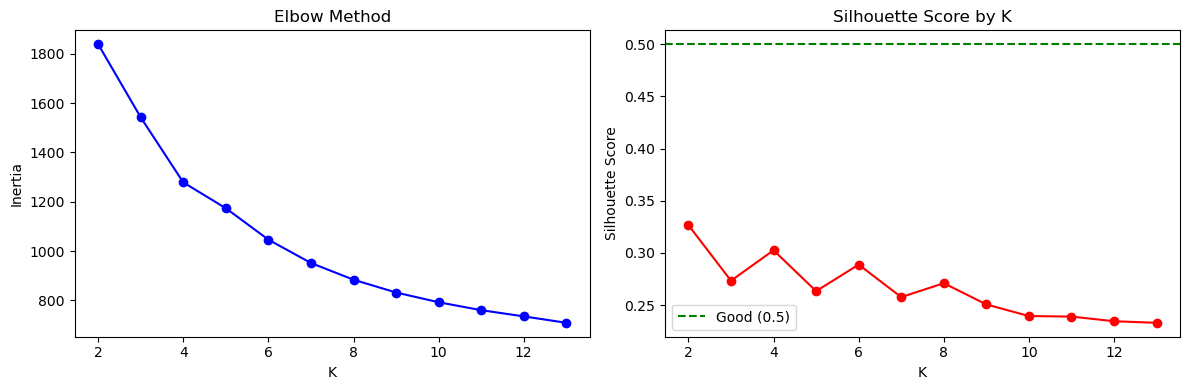

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertia_kmeans, 'bo-')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores_kmeans, 'ro-')
axes[1].axhline(y=0.5, color='g', linestyle='--', label='Good (0.5)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].legend()
plt.tight_layout()
plt.show()

부여된 가중치 찾기
가중치 제곱합이 1

In [12]:
weightA = pca_A.components_[0]  # shape: (4,)

weightD = pca_D.components_[0]
weightE = pca_E.components_[0]
weightF = pca_F.components_[0]
weightG = pca_G.components_[0]
weightH = pca_H.components_[0]

print(weightA)
print(weightD)
print(weightE)
print(weightF)
print(weightG)
print(weightH)

[0.62084859 0.29645762 0.19892386 0.61603664 0.32800621]
[0.15547753 0.98405687 0.08636443]
[0.93479486 0.35518808]
[0.14295567 0.98972909]
[ 0.04194424 -0.07062179  0.99662091]
[1.]


k=6에서 그나마 실루엣 스코어가 좋은거 같아서(0.37) 시각화 ->

# 2차원

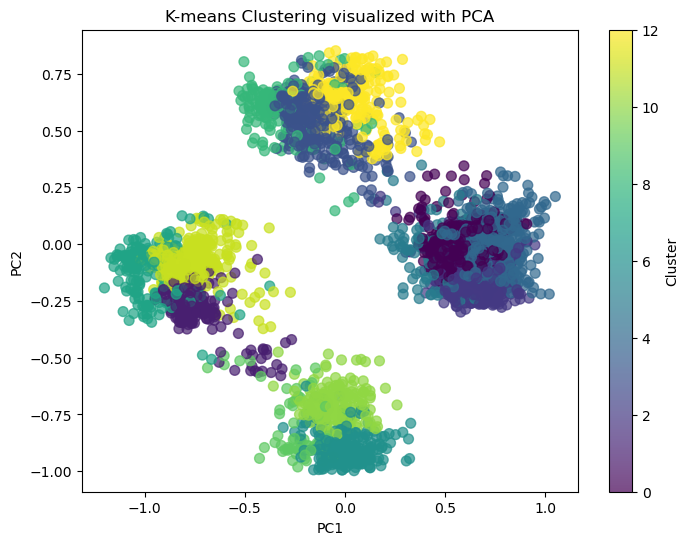

In [13]:
kmeans_k6 = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels_k6 = kmeans.fit_predict(PCA_weighted_df)

pca_vis_2d = PCA(n_components=2)
X_pca_2d = pca_vis_2d.fit_transform(PCA_weighted_df)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels_k6, cmap='viridis', s=50, alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clustering visualized with PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()

# 3차원

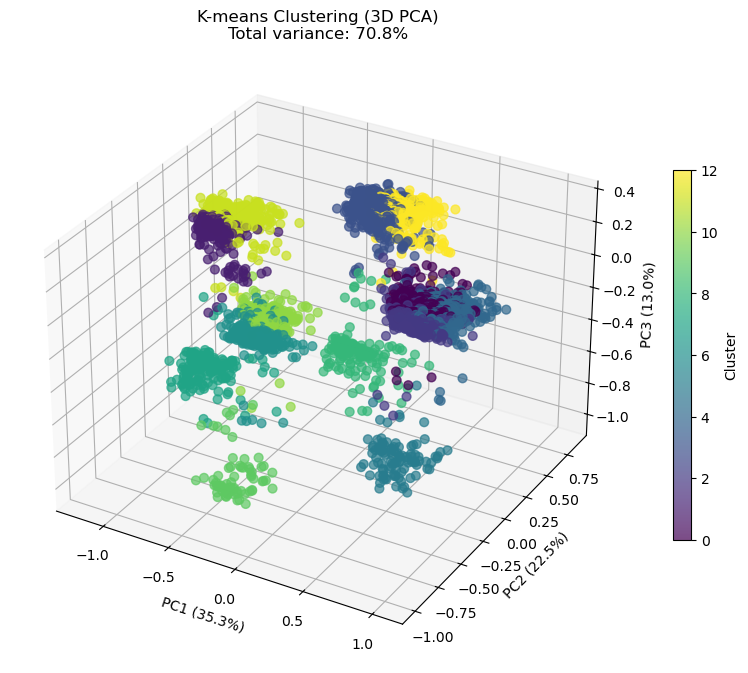

In [14]:
pca_vis_3d = PCA(n_components=3)
X_pca_3d = pca_vis_3d.fit_transform(PCA_weighted_df)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                     c=cluster_labels_k6, cmap='viridis', s=40, alpha=0.7)

ax.set_xlabel(f'PC1 ({pca_vis_3d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_vis_3d.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca_vis_3d.explained_variance_ratio_[2]:.1%})')
ax.set_title(f'K-means Clustering (3D PCA)\nTotal variance: {sum(pca_vis_3d.explained_variance_ratio_):.1%}')

plt.colorbar(scatter, label='Cluster', shrink=0.6)
plt.show()

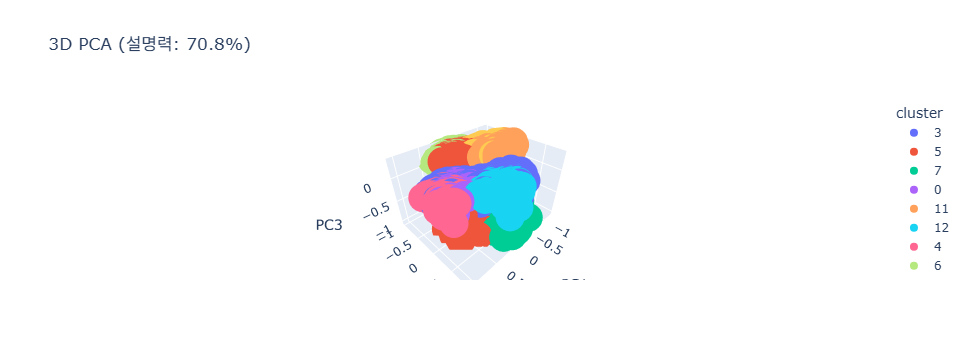

In [15]:
import plotly.express as px
#다른 버전 (ai가 만든거라 저도 뭐가 뭔지 몰라요~)
df_00 = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_00['cluster'] = cluster_labels_k6.astype(str)

fig = px.scatter_3d(df_00, x='PC1', y='PC2', z='PC3', color='cluster',
                    title=f'3D PCA (설명력: {sum(pca_vis_3d.explained_variance_ratio_):.1%})')
fig.show()